<a href="https://colab.research.google.com/github/goitstudent123/numerical_programming_python/blob/main/%D0%94%D0%976_%D0%93%D0%90%D0%A1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [18]:
# 1. Вибірка класів 'dog' та 'chirping_birds' + побудова шляхів до файлів

import os
import zipfile
from urllib.request import urlretrieve
import pandas as pd

# download + unpack if not exists
base_dir = "./ESC-50-data/"
repo_zip_path = os.path.join(base_dir, "ESC-50-master.zip")
extract_dir = os.path.join(base_dir, "ESC-50-master")

os.makedirs(base_dir, exist_ok=True)

url = "https://github.com/karoldvl/ESC-50/archive/master.zip"

if not os.path.exists(extract_dir):
    urlretrieve(url, repo_zip_path)
    with zipfile.ZipFile(repo_zip_path, 'r') as zip_ref:
        zip_ref.extractall(base_dir)
    os.remove(repo_zip_path)

meta_csv_path = os.path.join(extract_dir, "meta", "esc50.csv")
df = pd.read_csv(meta_csv_path)


# 1. Для зменшення обсягу даних зробити вибірку звуків із мітками 'dog' та 'chirping_birds'.
target_labels = ['dog', 'chirping_birds']
df_subset = df[df['category'].isin(target_labels)].reset_index(drop=True)

# dataset layout is flat: audio/<filename>.wav
audio_base = os.path.join(extract_dir, "audio")
df_subset["filepath"] = df_subset.apply(
    lambda row: os.path.join(audio_base, row["filename"]),
    axis=1
)

df_subset.head()


,filename,fold,target,category,esc10,src_file,take,filepath
0,1-100032-A-0.wav,1,0,dog,True,100032,A,./ESC-50-data/ESC-50-master/audio/1-100032-A-0...
1,1-100038-A-14.wav,1,14,chirping_birds,False,100038,A,./ESC-50-data/ESC-50-master/audio/1-100038-A-1...
2,1-110389-A-0.wav,1,0,dog,True,110389,A,./ESC-50-data/ESC-50-master/audio/1-110389-A-0...
3,1-30226-A-0.wav,1,0,dog,True,30226,A,./ESC-50-data/ESC-50-master/audio/1-30226-A-0.wav
4,1-30344-A-0.wav,1,0,dog,True,30344,A,./ESC-50-data/ESC-50-master/audio/1-30344-A-0.wav


In [20]:
# 2. За допомогою наведеної в конспекті функції spectrogram згенерувати матрицю спектрограми.

import librosa
import numpy as np

def compute_spectrogram(
    filepath,
    n_fft=1024,
    hop_length=512,
    to_db=True
):
    y, sr = librosa.load(filepath, sr=None)
    S = np.abs(librosa.stft(y, n_fft=n_fft, hop_length=hop_length))
    if to_db:
        S = librosa.amplitude_to_db(S, ref=np.max)
    return S, sr

example_path = df_subset.loc[0, "filepath"]
spec_matrix, sr = compute_spectrogram(example_path)
print("spec_matrix shape:", spec_matrix.shape, "sample_rate:", sr)


spec_matrix shape: (513, 431) sample_rate: 44100


In [21]:
# 3. Використати функцію pooling для узагальнення та зменшення розміру спектрограми.

import numpy as np

def pooling(spec, pool_size=(4, 4)):
    ph, pw = pool_size
    h, w = spec.shape

    h_cut = h - (h % ph)
    w_cut = w - (w % pw)

    spec_cropped = spec[:h_cut, :w_cut]

    spec_reshaped = spec_cropped.reshape(
        h_cut // ph, ph,
        w_cut // pw, pw
    )

    pooled = spec_reshaped.mean(axis=(1, 3))
    return pooled

pooled_example = pooling(spec_matrix, pool_size=(4, 4))
print("pooled shape:", pooled_example.shape)


pooled shape: (128, 107)


In [22]:
# 4. За допомогою методу flaten() перетворити матрицю спектрограми у вектор для подальшого спектрального аналізу.

flat_example = pooled_example.flatten()
print("flat vector length:", len(flat_example))
print("first 10 values:", flat_example[:10])


flat vector length: 13696
first 10 values: [-80. -80. -80. -80. -80. -80. -80. -80. -80. -80.]


In [23]:
# 5. Використати функцію SpectralClustering бібліотеки sklearn для кластеризації отриманих даних (аналогічно до ДЗ теми №1).

from sklearn.cluster import SpectralClustering

# feature extraction helper
def extract_feature_vector(
    filepath,
    max_frames=200,
    n_fft=1024,
    hop_length=512,
    pool_size=(4,4)
):
    y, sr = librosa.load(filepath, sr=None)
    S = np.abs(librosa.stft(y, n_fft=n_fft, hop_length=hop_length))
    S = librosa.amplitude_to_db(S, ref=np.max)

    # time truncate for consistent length
    S = S[:, :max_frames]

    P = pooling(S, pool_size=pool_size)
    return P.flatten()

# build feature matrix (truncate all to same length)
feature_list = []
labels_true = []

for _, row in df_subset.iterrows():
    vec = extract_feature_vector(row["filepath"])
    feature_list.append(vec)
    labels_true.append(row["category"])

import numpy as np
X_features = np.vstack(feature_list)
y_true = np.array(labels_true)

print("X_features:", X_features.shape)
print("classes in y_true:", np.unique(y_true))

# clustering
clustering = SpectralClustering(
    n_clusters=2,
    affinity='nearest_neighbors',
    assign_labels='kmeans',
    random_state=42
)

cluster_labels = clustering.fit_predict(X_features)
print("cluster_labels[:20] =", cluster_labels[:20])


X_features: (80, 6400)
classes in y_true: ['chirping_birds' 'dog']
cluster_labels[:20] = [0 1 0 0 0 0 1 1 1 1 1 0 1 0 0 0 1 1 1 0]


In [24]:
# 6. Проаналізувати отримані кластери. Чи потрапили в різні кластери звуки різного походження?

import pandas as pd

results_df = pd.DataFrame({
    "true_label": y_true,
    "cluster": cluster_labels
})

# contingency table
ct = pd.crosstab(results_df["cluster"], results_df["true_label"])
print("cluster vs true_label:")
print(ct)

# purity of each cluster
purity = ct.max(axis=1) / ct.sum(axis=1)
print("\npurity per cluster:")
print(purity)

# quick intuition
for clust_id in sorted(results_df["cluster"].unique()):
    subset = results_df[results_df["cluster"] == clust_id]["true_label"].value_counts(normalize=True)
    print(f"\ncluster {clust_id} composition:")
    print(subset)


cluster vs true_label:
true_label  chirping_birds  dog
cluster                        
0                       13   37
1                       27    3

purity per cluster:
cluster
0    0.74
1    0.90
dtype: float64

cluster 0 composition:
true_label
dog               0.74
chirping_birds    0.26
Name: proportion, dtype: float64

cluster 1 composition:
true_label
chirping_birds    0.9
dog               0.1
Name: proportion, dtype: float64


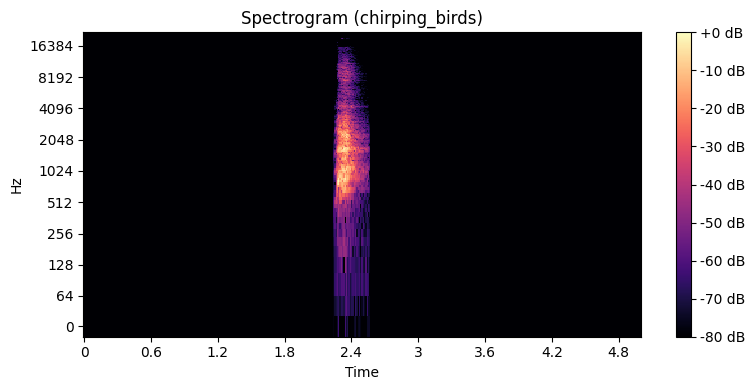

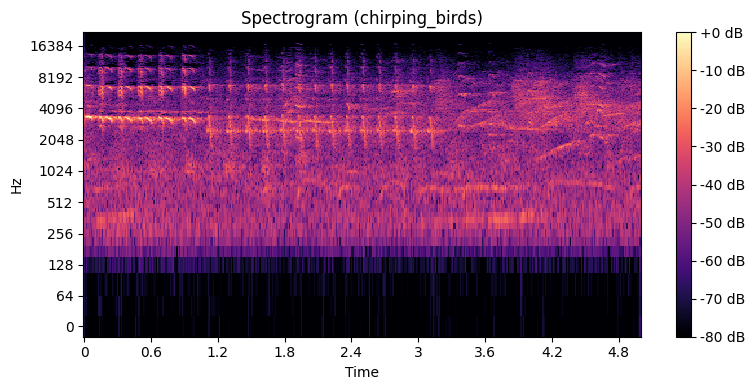

In [25]:
import matplotlib.pyplot as plt
import librosa.display

# приклади
example_dog = df_subset[df_subset["category"] == "dog"].iloc[0]["filepath"]
example_bird = df_subset[df_subset["category"] == "chirping_birds"].iloc[0]["filepath"]

for path in [example_dog, example_bird]:
    label = "dog" if "dog" in path else "chirping_birds"
    S, sr = compute_spectrogram(path)
    plt.figure(figsize=(8, 4))
    librosa.display.specshow(S, sr=sr, x_axis='time', y_axis='log', cmap='magma')
    plt.title(f"Spectrogram ({label})")
    plt.colorbar(format="%+2.0f dB")
    plt.tight_layout()
    plt.show()

# 7. Зробити висновок про значення застосування перетворення Фур'є для вилучення ознак даних.

Перетворення Фур'є переводить аудіосигнал із часової області в частотну область. Ми отримуємо спектрограму, яка показує, які частоти активні у кожний момент часу.

Pooling стискає спектрограму до компактнішого набору усереднених частотно-часових блоків.
Після flatten ми отримуємо вектор фіксованої довжини, який можна подати у стандартні алгоритми машинного навчання.

Clustering на цих векторах зміг повністю, або частково, розділити "dog" та "chirping_birds".

Це означає, що спектральна структура гавкоту відрізняється від співу птахів, і ця різниця вже помітна без ручної розмітки класів.

Висновок: перетворення Фур'є дозволяє вилучити інформативні ознаки зі звуку, які роблять можливими задачі класифікації та кластеризації.
